<a href="https://colab.research.google.com/github/sapienology/deep-learning-projects/blob/main/liver%20patient%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df1 = pd.read_csv('/content/liver_patient_dataset.csv')

In [3]:
df1

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB


In [5]:
df1['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [6]:
df1['Gender'] = df1['Gender'].replace({'Female' : 0 ,
                                       'Male' : 1})

In [7]:
df1['Selector'].unique()

array(['Liver Disease', 'No Liver Disease'], dtype=object)

In [8]:
df1['Selector'] = df1['Selector'].replace({'Liver Disease' : 0 ,
                                       'No Liver Disease' : 1})

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    int64  
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 50.2 KB


In [10]:
df1['Selector'].value_counts()

,count
Selector,
0,416
1,167


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df1.drop(columns = ['Selector'])

In [13]:
y = df1['Selector']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
log = LogisticRegression()

In [17]:
log.fit(X_train,y_train)

LogisticRegression()

In [18]:
pred = log.predict(X_test)

In [19]:
pred

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1])

In [20]:
from sklearn.metrics import classification_report

In [21]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85        87
           1       0.50      0.17      0.25        30

    accuracy                           0.74       117
   macro avg       0.63      0.55      0.55       117
weighted avg       0.70      0.74      0.69       117



HyperParameter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
log_param = {"C":[0.1,1], "penalty":["l1","l2"]}

In [24]:
grid = GridSearchCV(
    LogisticRegression(),
    log_param
)

In [25]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1], 'penalty': ['l1', 'l2']})

In [26]:
grid.best_estimator_

LogisticRegression(C=0.1)

In [27]:
grid_pred = grid.predict(X_test)

In [28]:
print(classification_report(y_test,grid_pred))

              precision    recall  f1-score   support

           0       0.77      0.97      0.86        87
           1       0.62      0.17      0.26        30

    accuracy                           0.76       117
   macro avg       0.70      0.57      0.56       117
weighted avg       0.73      0.76      0.70       117



Data Normalization

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
sm = SMOTE(random_state=42)

In [31]:
X_resampled, y_resampled = sm.fit_resample(X,y)

In [32]:
y_resampled.value_counts()

,count
Selector,
0,416
1,416


In [33]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

In [36]:
scaled_X_train = scaler.fit_transform(X_train_new)

In [37]:
scaled_X_test = scaler.transform(X_test_new)

In [38]:
logistic = LogisticRegression()

In [39]:
logistic.fit(scaled_X_train,y_train_new)

LogisticRegression()

In [40]:
pred_new = logistic.predict(scaled_X_test)

In [41]:
print(classification_report(y_test_new,pred_new))

              precision    recall  f1-score   support

           0       0.73      0.68      0.70        75
           1       0.75      0.79      0.77        92

    accuracy                           0.74       167
   macro avg       0.74      0.74      0.74       167
weighted avg       0.74      0.74      0.74       167



In [42]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    # ── Input ──
    layers.Input(shape=(10,), name="input_layer"),

    # ── Hidden Layer 1 ──
    layers.Dense(16, activation="relu", name="hidden_1"),
    layers.Dropout(0.2, name="dropout_1"),

    # ── Hidden Layer 2 ──
    layers.Dense(8, activation="relu", name="hidden_2"),
    layers.Dropout(0.2, name="dropout_2"),

    # ── Output ──
    layers.Dense(1, activation="sigmoid", name="output_layer"),
], name="student_pass_predictor")

model.summary()


Model: "student_pass_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile: choose optimizer, loss, and metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",   # standard loss for binary classification
    metrics=["accuracy"]
)

print("✅ Model compiled!")
print("\nKey choices:")
print("  Optimizer  : Adam (adaptive learning rate — great default choice)")
print("  Loss       : Binary Crossentropy (for 0/1 output)")
print("  Metric     : Accuracy (% correct predictions)")


✅ Model compiled!

Key choices:
  Optimizer  : Adam (adaptive learning rate — great default choice)
  Loss       : Binary Crossentropy (for 0/1 output)
  Metric     : Accuracy (% correct predictions)


In [44]:
history = model.fit(
    X_train_new, y_train_new,
    epochs= 100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

print("\n✅ Training complete!")


Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4831 - loss: 24.2172 - val_accuracy: 0.4511 - val_loss: 5.9288
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5075 - loss: 8.7841 - val_accuracy: 0.6466 - val_loss: 0.6286
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5244 - loss: 7.1349 - val_accuracy: 0.5414 - val_loss: 0.6593
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5244 - loss: 4.9973 - val_accuracy: 0.5865 - val_loss: 0.6549
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5602 - loss: 4.0951 - val_accuracy: 0.5865 - val_loss: 0.7096
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5583 - loss: 3.1277 - val_accuracy: 0.5714 - val_loss: 0.7199
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5432 - loss: 3.1087 - val_accuracy: 0.5714 - val_loss: 0.7583
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5677 - loss: 2.2949 - val_accuracy: 0.6241 -

In [45]:
test_loss, test_acc = model.evaluate(X_test_new, y_test_new, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.1f}%")


Test Loss     : 0.6136
Test Accuracy : 67.7%


=== Classification Report ===
              precision    recall  f1-score   support

        FAIL       0.72      0.45      0.56        75
        PASS       0.66      0.86      0.75        92

    accuracy                           0.68       167
   macro avg       0.69      0.66      0.65       167
weighted avg       0.69      0.68      0.66       167



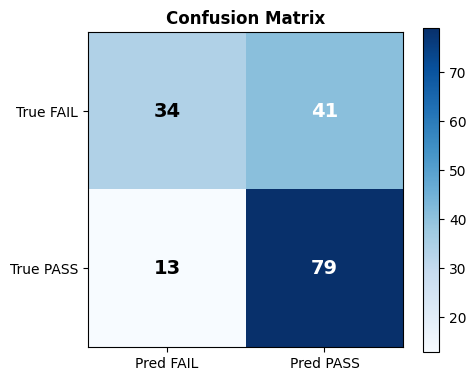


True Positives  (correctly predicted PASS): 79
True Negatives  (correctly predicted FAIL): 34
False Positives (predicted PASS, actually FAIL): 41
False Negatives (predicted FAIL, actually PASS): 13


In [46]:
# Predictions
y_pred_prob = model.predict(X_test_new, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)   # threshold at 0.5

print("=== Classification Report ===")
print(classification_report(y_test_new, y_pred, target_names=["FAIL", "PASS"]))

# Confusion matrix
cm = confusion_matrix(y_test_new, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred FAIL","Pred PASS"]); ax.set_yticklabels(["True FAIL","True PASS"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
ax.set_title("Confusion Matrix", fontweight="bold")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nTrue Positives  (correctly predicted PASS):", cm[1,1])
print("True Negatives  (correctly predicted FAIL):", cm[0,0])
print("False Positives (predicted PASS, actually FAIL):", cm[0,1])
print("False Negatives (predicted FAIL, actually PASS):", cm[1,0])

In [47]:
tf.random.set_seed(42)
np.random.seed(42)

model = keras.Sequential([
    # ── Input ──
    layers.Input(shape=(10,), name="input_layer"),

    # ── Hidden Layer 1 ──
    layers.Dense(16, activation="relu", name="hidden_1"),
    layers.Dropout(0.2, name="dropout_1"),

    # ── Hidden Layer 2 ──
    layers.Dense(8, activation="relu", name="hidden_2"),
    layers.Dropout(0.2, name="dropout_2"),

    # ── Output ──
    layers.Dense(2, activation="softmax", name="output_layer"),
], name="student_pass_predictor")

model.summary()

Model: "student_pass_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330 (1.29 KB)

 Trainable params: 330 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Compile: choose optimizer, loss, and metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # standard loss for binary classification
    metrics=["accuracy"]
)

print("✅ Model compiled!")
print("\nKey choices:")
print("  Optimizer  : Adam (adaptive learning rate — great default choice)")
print("  Loss       : Binary Crossentropy (for 0/1 output)")
print("  Metric     : Accuracy (% correct predictions)")


✅ Model compiled!

Key choices:
  Optimizer  : Adam (adaptive learning rate — great default choice)
  Loss       : Binary Crossentropy (for 0/1 output)
  Metric     : Accuracy (% correct predictions)


In [49]:
history = model.fit(
    X_train_new, y_train_new,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

print("\n✅ Training complete!")


Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5188 - loss: 32.8230 - val_accuracy: 0.4586 - val_loss: 8.1460
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 14.0822 - val_accuracy: 0.4586 - val_loss: 2.5575
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5019 - loss: 11.7267 - val_accuracy: 0.5263 - val_loss: 1.4514
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5263 - loss: 7.4348 - val_accuracy: 0.6015 - val_loss: 1.0265
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5094 - loss: 6.8283 - val_accuracy: 0.5940 - val_loss: 0.7253
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5414 - loss: 3.8918 - val_accuracy: 0.6165 - val_loss: 0.6705
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5414 - loss: 3.3184 - val_accuracy: 0.6241 - val_loss: 0.5934
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5376 - loss: 3.0068 - val_accuracy: 0.5789 

In [50]:
test_loss, test_acc = model.evaluate(X_test_new, y_test_new, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.1f}%")

Test Loss     : 0.6603
Test Accuracy : 58.7%


In [ ]:
# Predictions
# Predict probabilities
y_pred_prob = model.predict(X_test_new, verbose=0)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("=== Classification Report ===")
print(classification_report(
    y_test_new,
    y_pred,
    target_names=["FAIL", "PASS"]
))

# Confusion matrix
cm = confusion_matrix(y_test_new, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred FAIL","Pred PASS"]); ax.set_yticklabels(["True FAIL","True PASS"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
ax.set_title("Confusion Matrix", fontweight="bold")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nTrue Positives  (correctly predicted PASS):", cm[1,1])
print("True Negatives  (correctly predicted FAIL):", cm[0,0])
print("False Positives (predicted PASS, actually FAIL):", cm[0,1])
print("False Negatives (predicted FAIL, actually PASS):", cm[1,0])